## Exposure Time Calculator v.2

An updated, more streamlined notebook that builds off of our first design (ETC_Ian.ipynb)

Goals here:
1. Add airmass attenuation to TP params
2. Make TP curves more defined, add plots for fiber/lens attenuation
3. Make whole system modular

In [1]:
#import libs:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import h, c
from astropy.table import Table
from scipy.interpolate import interp1d
from scipy import integrate
from specreduce.calibration_data import AtmosphericExtinction, SUPPORTED_EXTINCTION_MODELS
from shared_data import CSV_FILES, REFERENCE_SPECTRA

In [2]:
#load in all csv files
dtype = [('wave', float), ('tp', float)]

QHY_qe = np.sort(np.genfromtxt(CSV_FILES["qhy268_qe"], dtype=dtype, delimiter=","))
Kepler_qe = np.sort(np.genfromtxt(CSV_FILES["KL400BI_qe"], dtype=dtype, delimiter=","))
Kepler_qe['tp'] /= 100
Moravian_qe = np.sort(np.genfromtxt(CSV_FILES["Moravian_qe"], dtype=dtype, delimiter=","))
Moravian_qe['tp'] /= 100

grat_1294_up = np.sort(np.genfromtxt(CSV_FILES["master 1294 unpolarized"], dtype=dtype, delimiter=","))
grat_1229_P = np.sort(np.genfromtxt(CSV_FILES["master 1229 P plane"], dtype=dtype, delimiter=","))
grat_1229_S = np.sort(np.genfromtxt(CSV_FILES["master 1229 S plane"], dtype=dtype, delimiter=","))

fiber_att = np.sort(np.genfromtxt(CSV_FILES["fiber_attenuation"], dtype=dtype, delimiter=","))
#convert fiber attenuation values from dB/km to %:
fiber_att['tp'] = 10**(-(fiber_att['tp'] * 0.01)/10)

### Obtain all throughput curves (qe, grating, fiber attenuation, airmass extinction)

In [3]:
#Camera qe curve
def get_qe(wave_nm, camera='QHY268'):
    """takes wavelength in nm and returns QE value at that wavelength.""" 
    if camera == 'QHY268':
        camera_qe = QHY_qe
    elif camera == 'Kepler':
        camera_qe = Kepler_qe
    elif camera == 'Moravian':
        camera_qe = Moravian_qe
    else:
        raise(ValueError(f"Entered camera name ({camera}) is invalid. Accepted names are 'QHY268', 'Kepler', & 'Moravian'."))
    qe_curve = interp1d(camera_qe['wave'], camera_qe['tp'], kind='cubic', bounds_error=False, fill_value=np.nan)
    return float(qe_curve(wave_nm))

In [4]:
#1229 Grating: need to average both curves

std_wave_grid = np.arange(314, 901)

grats_1229_polar = [grat_1229_P, grat_1229_S]

polar_grat_tps = []

for polarization in grats_1229_polar:

    interp = interp1d(polarization['wave'], polarization['tp'], kind='linear', bounds_error=False, fill_value='extrapolate')

    polar_grat_tps.append(interp(std_wave_grid))

mean_1229 = np.nanmean(polar_grat_tps, axis=0)


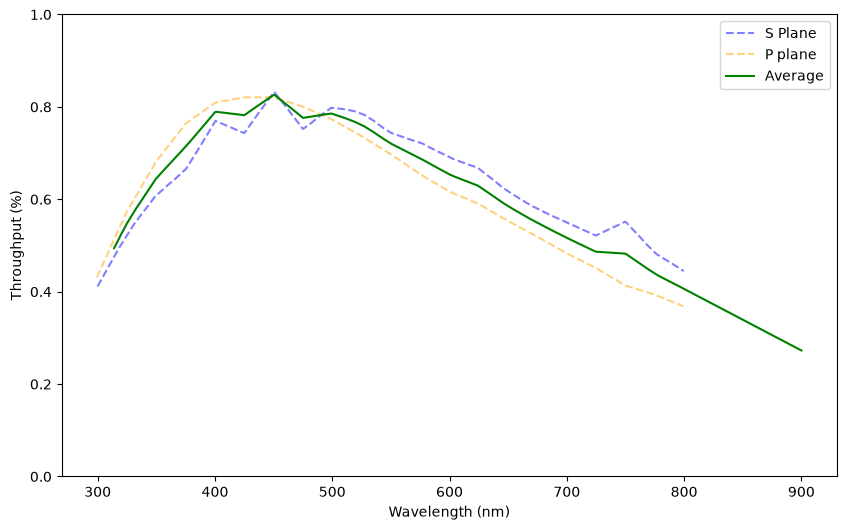

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(grat_1229_S['wave'], grat_1229_S['tp'], c='blue', ls='--', alpha=0.5, label='S Plane')
plt.plot(grat_1229_P['wave'], grat_1229_P['tp'], c='orange', ls='--', alpha=0.5, label='P plane')
plt.plot(std_wave_grid, mean_1229, c='green', label= 'Average')
plt.ylim(0, 1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Throughput (%)')
plt.legend()
plt.show()

In [6]:
def get_gr(wave_nm, grat_master_num):
    """takes wavelength in nm and returns grating efficiency value at that wavelength.""" 
    
    if grat_master_num == 1229:
        grat_curve = interp1d(std_wave_grid, mean_1229, kind='cubic', bounds_error=False, fill_value=np.nan)

    elif grat_master_num == 1294:
        grat_curve = interp1d(grat_1294_up['wave'], grat_1294_up['tp'], kind='cubic', bounds_error=False, fill_value=np.nan)

    else:
        raise ValueError(f"'{grat_master_num}' is not a recognized grating master number. Recognized values are '1229' and '1294'")
    
    return float(grat_curve(wave_nm))

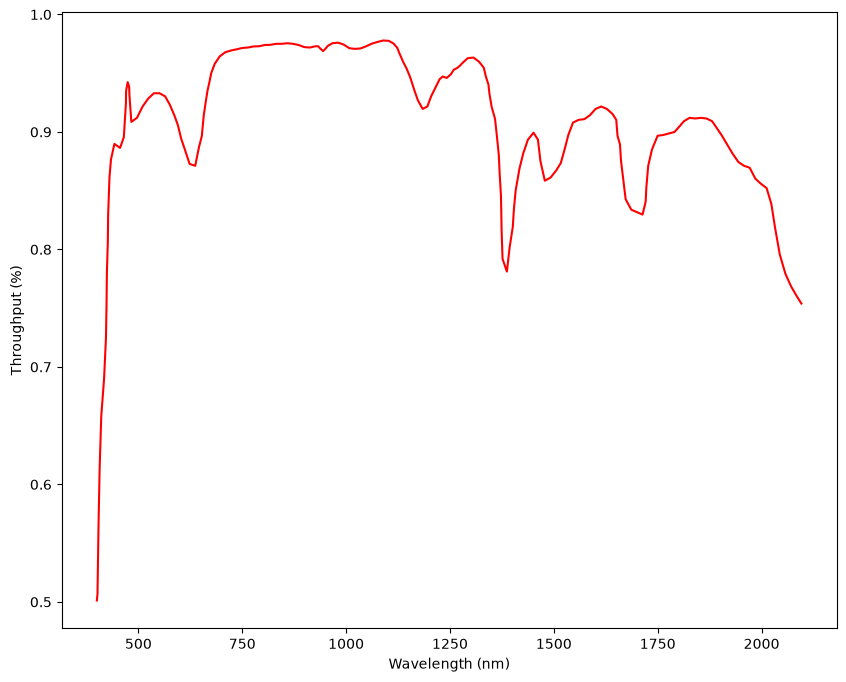

In [7]:
plt.figure(figsize=(10, 8))
plt.plot(fiber_att['wave'], fiber_att['tp'], c='red')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Throughput (%)')
plt.show()

In [8]:
fiber_curve = interp1d(fiber_att['wave'], fiber_att['tp'], kind='cubic', bounds_error=False, fill_value=np.nan)
def get_fib_att(wave_nm):
    """takes wavelength in nm and returns fiber attenuation value at that wavelength.""" 
    return float(fiber_curve(wave_nm))

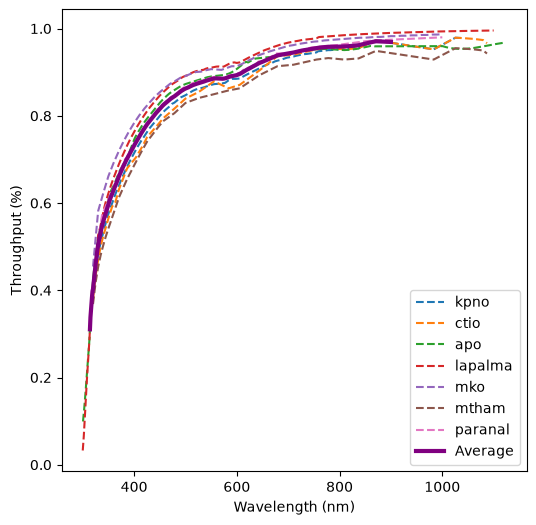

In [9]:
#airmass:

plt.figure(figsize=(6, 6))
interp_ext = []
for model in SUPPORTED_EXTINCTION_MODELS:
    ext = AtmosphericExtinction(model=model)
    plt.plot(ext.spectral_axis/10, ext.transmission, ls='--', label=model)
    interp = interp1d(ext.spectral_axis/10, ext.transmission, kind='linear', bounds_error=False, fill_value=np.nan)

    interp_ext.append(interp(std_wave_grid)) #use standard grid (created when I did the same thing for S/P polarization avg)

mean_airmass_models = np.nanmean(interp_ext, axis=0)
plt.plot(std_wave_grid, mean_airmass_models, lw=3, c='purple', label='Average')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Throughput (%)')
plt.legend()
plt.show()

In [10]:
def get_airmass_ext(wave_nm, model):

    if model == 'average':
        air_curve =  interp1d(std_wave_grid, mean_airmass_models, kind='cubic', bounds_error=False, fill_value=np.nan)
    elif model in SUPPORTED_EXTINCTION_MODELS:
        ext = AtmosphericExtinction(model=model)
        air_curve = interp1d(ext.spectral_axis/10, ext.transmission, kind='linear', bounds_error=False, fill_value=np.nan)
    else:
        raise(ValueError(f"Requested extinction model, '{model}', not in list of available models: ['kpno', 'ctio', 'apo', 'lapalma', 'mko', 'mtham', 'paranal', 'average']"))

    return float(air_curve(wave_nm))

In [11]:
get_airmass_ext(500, 'average')

0.8625284327671939

In [12]:
#dark current: not related to tp, but same logic:
plot_temps_dc = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
dc_vals = [0.00053145, 0.00062832, 0.001309,
            0.0018326, 0.0036652, 0.0059756, 0.010472, 0.019111, 0.036913]
dc_curve = interp1d(plot_temps_dc, dc_vals, kind='cubic', bounds_error=False, fill_value=0.0) #not necessary to extrapolate here

def get_dc(temp_C):
    """takes temperature in C  and returns dark current value at that temperature.""" 
    return float(dc_curve(temp_C))

### Find expressions for throughput/flux density for calculation of object/sky counts:

In [13]:
def get_tp(detec, grat, fiber, airmass, lens=0.99):
    """Obtains the total instrument throughput from individual components"""

    total_tp = fiber * grat * lens * detec * airmass
    
    return total_tp

In [14]:
def get_flux_density(wavelength, mag_ab):
    """Determines the wavelength-dependent flux-density with a given AB-mag
    
    Wavelength is in nanometers.
    """

    wavelength = wavelength * u.nm

    f_ab = 3631 * u.Jy * np.power(10, (-mag_ab/2.5))
    f_lambda = f_ab.to(u.W/(u.m**2 * u.nm), equivalencies = u.spectral_density(wavelength))
    
    return f_lambda

get_flux_density(500,18)

<Quantity 2.74730542e-18 W / (nm m2)>

### Develop functions to load a SN Ia spectrum:

In [15]:
def load_spectrum(dir, z):
    """loads a spectrum file and deredshifts it"""
    spec = np.genfromtxt(dir, dtype=[('wave', float), ('flux', float)])

    #de-redshift spectrum:
    a = 1/(1 + z)
    spec['wave'] *= a
    return spec

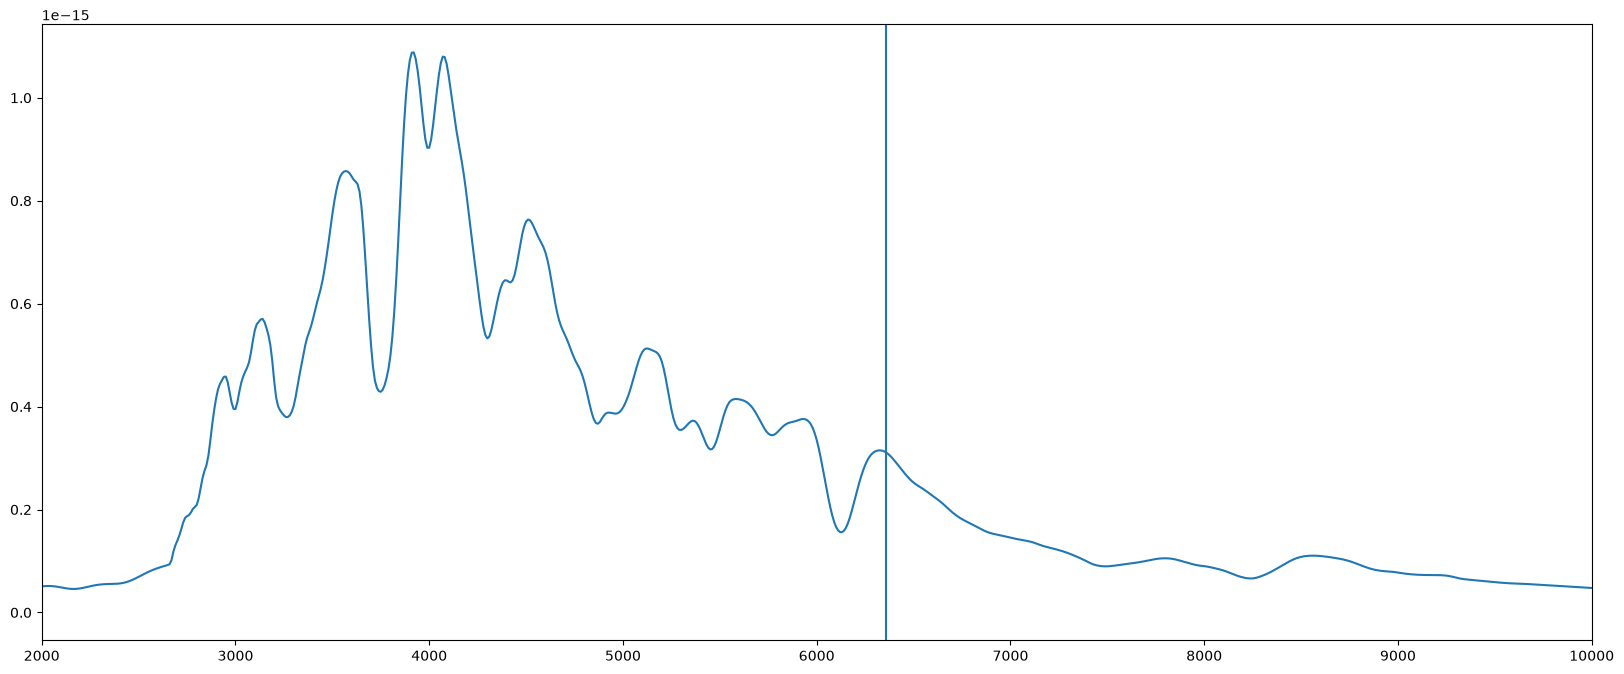

In [16]:
datadir = REFERENCE_SPECTRA["SNIa_max_z0p05"]

spec = load_spectrum(datadir, 0.05)
plt.figure(figsize=(20, 8))
plt.plot(spec['wave'], spec['flux'])
plt.xlim(2000, 10000)
plt.axvline(6355)
plt.show()

In [17]:
def get_sob_from_spec(spectrum, lens=0.99, t_diam = 1250, grat_master_num=1229, airmass_model='average', camera = 'QHY268'):

    s_obs = []
    fibers = []
    grats = []
    detecs = []
    airmasses = []
    for wave in spectrum['wave']:
        grat = np.clip(get_gr(wave, grat_master_num) - 0.1, 0, 1) #account for efficiency loss due to instrument design
        fiber = get_fib_att(wave)
        detec = get_qe(wave, camera)
        airmass = get_airmass_ext(wave, airmass_model)
        grats.append(grat)
        fibers.append(fiber)
        detecs.append(detec)
        airmasses.append(airmass)
        tp = get_tp(detec, grat, fiber, airmass, lens)
        f_lam = spectrum['flux'][spectrum['wave']==wave][0] * u.erg / (u.s * u.cm**2 * u.AA)

        t_area = np.pi * (((t_diam * u.mm).to(u.m))/2)**2

        s_ob = f_lam * (wave * u.nm)/(h * c) * t_area * tp

        s_obs.append(s_ob.to(1/(u.s * u.nm)).value)
    return s_obs, grats, detecs, fibers, airmasses

In [18]:
def get_sky_counts(spectrum, sky_mag, lens=0.99, t_diam=1250, grat_master_num=1229, airmass_model='average', camera = 'QHY268'):
    """Obtains the total wavelength-dependent sky counts using a sky_mag value in units of mag/arcsec^2"""
    sky_counts = []
    for wave in spectrum['wave']:
        grat = np.clip(get_gr(wave, grat_master_num) - 0.1, 0, 1) #account for efficiency loss due to instrument design
        detec = get_qe(wave, camera)
        fiber = get_fib_att(wave)
        airmass = get_airmass_ext(wave, airmass_model)
        tp = get_tp(detec, grat, fiber, airmass, lens)

        f_lam = get_flux_density(wave, sky_mag) / u.arcsec**2
        t_area = np.pi * (((t_diam * u.mm).to(u.m))/2)**2
        s_sky = f_lam * (wave * u.nm)/(h * c) * t_area * tp

        sky_counts.append(s_sky.to(1/(u.s * u.nm * u.arcsec**2)).value)

    return sky_counts


In [19]:
def get_SNR_from_spectrum(exp_time, datadir,z, wave_centers, binsize, dispersion=0.14, spacial_aperture=13, sky_brightness=21.6, 
                        read_noise_e=2.3, pix_scale = 0.8, grat_master_num=1229, airmass_model='average', camera = 'QHY_268', lens=0.99, t_diam=1250, temp=-10, 
                        value_output_only=False, show_plots=True):
    """determines the SNR at a given exposure time and set of wavelength bins using an observed spectrum"""
    
    wave_centers = np.array(wave_centers) #make np array for easy use later

    # User-communication pipeline: makes sure all inputs are correct type and within correct range:
    if np.any(wave_centers[(wave_centers - binsize < 400)]) or np.any(wave_centers[(wave_centers + binsize > 900)]) == np.True_:
       raise(ValueError(f'One or more wave bin centers ({wave_centers}) is outside instrument range with current binsize. Instrument range with chosen bin ({binsize}): {400+binsize} to {900-binsize} nm'))

    if (temp < -20) or (temp > 20):
      raise(ValueError(f'Entered temperature ({temp}) has no value for dark current (out of bounds). Known tempeature range: -20 to 20 C'))
    dark_current=get_dc(temp)
    
    if not binsize > 0:
       raise(ValueError('Bin size must be positive.'))

    #load spectrum file:
    spec = load_spectrum(datadir, z)
    spec['wave'] /= 10 #convert to nm to allign with tp figures
    print(f"Determining SNR using spectrum located at '{datadir}'....\n")
    print('Binning Parameters:\n------------------------')
    print(f'Bin centers: {wave_centers} nm\nBin size: {binsize} nm\n')

    
    #determine total number of pixels:
    n_wave = binsize/dispersion

    n_spacial = spacial_aperture #might need to change this later, good placeholder for now.

    n_total = n_wave * n_spacial

    # determine readout noise:
    read_noise_var = read_noise_e**2 * n_total

    #Evalutate dark current counts given pixel size/ exposure time:
    dark_counts = dark_current * n_total * exp_time

    #Output some values
    print('Photometric parameters:\n------------------------')
    print(f'Exposure time: {exp_time} s\nDispersion: {dispersion} nm/pix\nSpacial Aperture: {spacial_aperture} pix\nTotal Native Pixels: {n_total} pix\nPixel Scale: {pix_scale} (arcsec/pixel)')
    print(f'Camera temp: {temp} C\nDark current: {dark_counts:.3f} e ({dark_current} e/s/pix)\nTotal Read noise: {np.sqrt(read_noise_var):.3f} e\nAirmass Model: {airmass_model}')
    print(f'Telescope diameter: {t_diam} mm')

    #t = Table(names=('Wave Center (nm)', 'S_ob', 'SNR'), dtype=(str, 'f4', 'f4'))
    #evaluate SNR for each center:
    for center in wave_centers:
        print(f'\n{center} nm:')
        #determine object counts:
        wave_min = center - binsize/2
        wave_max = center + binsize/2
        w = (spec['wave'] >= wave_min) & (spec['wave'] <= wave_max) #constrain spectrum values to bin
        wave_bin = np.array(spec['wave'][w])

        s_obs, grats, detecs, fibers, airmasses = get_sob_from_spec(spec[w], lens, t_diam, grat_master_num, airmass_model, camera)

        s_ob_bin = integrate.simpson(s_obs, x=wave_bin)

        #determine sky counts
        s_sky = get_sky_counts(spec[w], sky_brightness, lens, t_diam, grat_master_num, airmass_model, camera)

        s_sky_bin = integrate.simpson(s_sky, x=wave_bin)

        #obtain total source counts in given exposure:
        source_counts = s_ob_bin * exp_time

        #obtain total sky counts in given exposure:
        extraction_area = n_total * pix_scale**2 #in arcsec^2
        sky_counts = s_sky_bin * exp_time * extraction_area
        
        snr_bin = source_counts/np.sqrt(source_counts + sky_counts + dark_counts + read_noise_var) #changed this to be more intuitive

        print('    Throughput parameters:\n    ------------------------')
        print(f'    Lenses: {lens:.3f}\n    Fiber Average: {np.mean(fibers):.3f}\n    Grating Average: {np.mean(grats):.3f}\n    Detector Average: {np.mean(detecs):.3f}')
        print(f'    Airmass Model Average: {np.mean(airmasses):.3f}')
        print(f'    Sky Counts: {sky_counts:.3f} phot ({s_sky_bin:.3f} phot/s)\n    Object Counts: {source_counts:.3f} phot ({s_ob_bin:.3f} phot/s)\n    SNR: {snr_bin:.3f}')

In [20]:
get_SNR_from_spectrum(600, datadir, 0.05, [600, 700], 5, grat_master_num=1294, camera='Kepler', read_noise_e=3.9)

Determining SNR using spectrum located at '/home/Master_Control/MLO-Spectrograph/data/SN_ref_spectra/SNIa_max_z0p05.txt'....

Binning Parameters:
------------------------
Bin centers: [600 700] nm
Bin size: 5 nm

Photometric parameters:
------------------------
Exposure time: 600 s
Dispersion: 0.14 nm/pix
Spacial Aperture: 13 pix
Total Native Pixels: 464.2857142857142 pix
Pixel Scale: 0.8 (arcsec/pixel)
Camera temp: -10 C
Dark current: 364.650 e (0.001309 e/s/pix)
Total Read noise: 84.034 e
Airmass Model: average
Telescope diameter: 1250 mm

600 nm:
    Throughput parameters:
    ------------------------
    Lenses: 0.990
    Fiber Average: 0.899
    Grating Average: 0.627
    Detector Average: 0.009
    Airmass Model Average: 0.893
    Sky Counts: 856.702 phot (0.005 phot/s)
    Object Counts: 138.750 phot (0.231 phot/s)
    SNR: 1.512

700 nm:
    Throughput parameters:
    ------------------------
    Lenses: 0.990
    Fiber Average: 0.966
    Grating Average: 0.516
    Detector Ave